In [7]:
%load_ext autoreload
%autoreload 2

### Global Variables
DATA_SAVE_PATH = "../../../models/used_data"
DAYS_PER_EPISODE = 3
TRAIN_TEST_SPLIT_FRACTION = 0.2  # Amount of data you reserve for testing.
BUFFER_DAYS = 3  # Amount of days that needs to be between the test episodes.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from Simulation.suite_simple_trading.pre_processing import clean_data
import pandas as pd
import os
from Simulation.suite_simple_trading.data_splitting import get_or_create_train_test_split

### Getting data

raw_data_path = '../../../data/2025_minute.csv'
cleaned_data_cache_path = '../../../data/2025_minute_cleaned.pkl'

if os.path.exists(cleaned_data_cache_path):
    print(f"Loading cached cleaned data from: {cleaned_data_cache_path}")
    cleaned_df = pd.read_pickle(cleaned_data_cache_path)
else:
    print("No cached data found. Running the full cleaning process...")
    raw_df = pd.read_csv(raw_data_path, sep=';')
    cleaned_df = clean_data(raw_df)
    print(f"Saving cleaned data to cache: {cleaned_data_cache_path}")
    cleaned_df.to_pickle(cleaned_data_cache_path)

all_data = cleaned_df[['Datetime', 'Imbalance Price']]
train_df, test_df, nr_of_episodes = get_or_create_train_test_split(
    all_data=all_data,
    save_path=DATA_SAVE_PATH,
    days_per_episode=DAYS_PER_EPISODE,
    test_fraction=TRAIN_TEST_SPLIT_FRACTION,
    buffer_days=BUFFER_DAYS
)

Loading cached cleaned data from: ../../../data/2025_minute_cleaned.pkl
--- Loading existing train/test data from '../../../models/used_data' ---
--- Data loaded successfully. Found 19 test episodes. ---
Test Data Size / Train Data Size: 0.25


In [51]:
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib import MaskablePPO
from Simulation.suite_simple_trading.observation_wrappers import RobustScalingWrapper
### The model (Environment) used in all agents

from Simulation.suite_simple_trading.model import TimeAwareBatteryEnv, ExtendedBatteryEnv

train_env = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs = RobustScalingWrapper(train_env)
ppo_agent = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_obs, n_steps=4096, ent_coef=0.01)
ppo_agent.learn(total_timesteps=200_000, progress_bar=True)


Output()

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [10]:
train_env_compare = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs_compare = RobustScalingWrapper(train_env_compare)
ppo_agent_compare = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_obs_compare)
ppo_agent_compare.learn(total_timesteps=100_000, progress_bar=True)


Output()

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [52]:
from Simulation.suite_simple_trading.policy import PPOAgentDecisionMaker
from Simulation.suite_simple_trading.simulation import run_evaluation

### Testing
test_env = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled = RobustScalingWrapper(test_env)
decision_maker_PPO = PPOAgentDecisionMaker(ppo_agent, test_env_scaled)

result_ppo = run_evaluation(test_env_scaled,
                            ppo_agent, number_of_episodes=nr_of_episodes)
print(f"reward ppo: {sum(result_ppo["real_rewards"])}")
result_ppo.pop("episodic_rewards")
history_df = pd.DataFrame(result_ppo)
history_df['Datetime'] = test_df['Datetime']


--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 9012.22
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 1238.32
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 6962.46
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 2321.34
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 1068.09
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 7454.51
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total 

In [54]:
from Simulation.suite_simple_trading.metrics import print_agent_performance

print_agent_performance(history_df, "PPO Agent with time aware features")

  PERFORMANCE REPORT: PPO Agent with time aware features
  Pos. Profit Quarters : 145
  Neg. Profit Quarters : 74
----------------------------------------
  Success Rate (Active): 66.21%
  Mean Reward / active Quarter: €46.5450
----------------------------------------
  'Trap' Quarters      : 9
  (Started good -> Ended bad)



In [16]:
### Testing
test_env_compare = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled_compare = RobustScalingWrapper(test_env_compare)

result_ppo_compare = run_evaluation(test_env_scaled_compare,
                            ppo_agent_compare, number_of_episodes=nr_of_episodes)
print(f"reward ppo: {sum(result_ppo_compare["real_rewards"])}")
result_ppo_compare.pop("episodic_rewards")
history_df_compare = pd.DataFrame(result_ppo_compare)
history_df_compare['Datetime'] = test_df['Datetime']


--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 8767.59
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 1242.76
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 7506.16
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 2224.20
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 1250.48
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 7977.16
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total 

In [39]:
print_agent_performance(history_df_compare, "PPO Agent Without, to compare")


  PERFORMANCE REPORT: PPO Agent Without, to compare
  Pos. Profit Quarters : 112
  Neg. Profit Quarters : 55
----------------------------------------
  Success Rate (Active): 67.07%
  Mean Reward / active Quarter: €59.5704
----------------------------------------
  'Trap' Quarters      : 9
  (Started good -> Ended bad)



Saving plot to: plots/test_scaling_reward


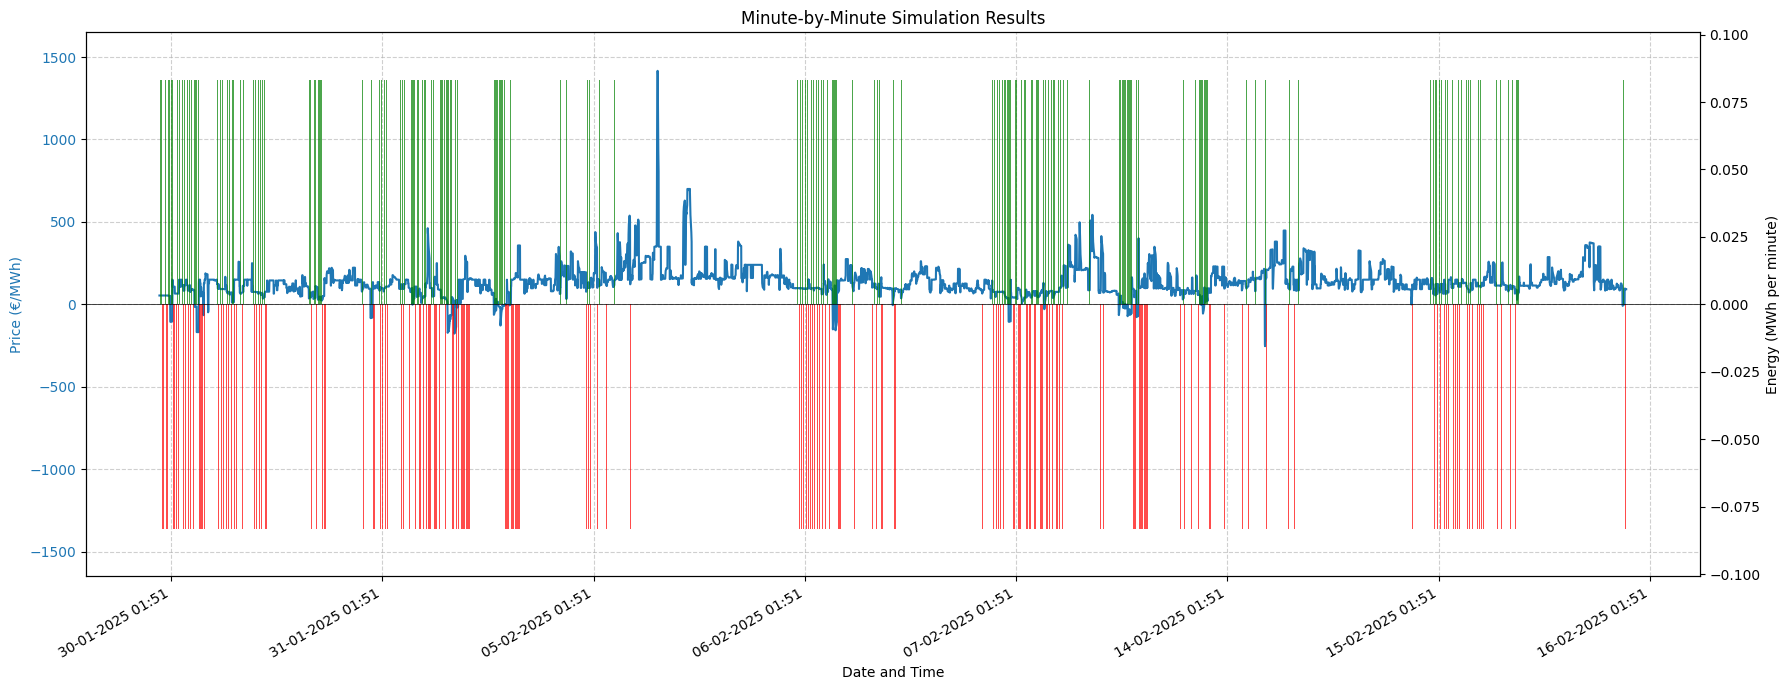

In [55]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute, plot_feature_importance

plot_simulation_results_minute_by_minute(
    history_df,
    "test_scaling_reward",
    10_000,
    20_000
)

Saving plot to: plots/test_scaling_reward


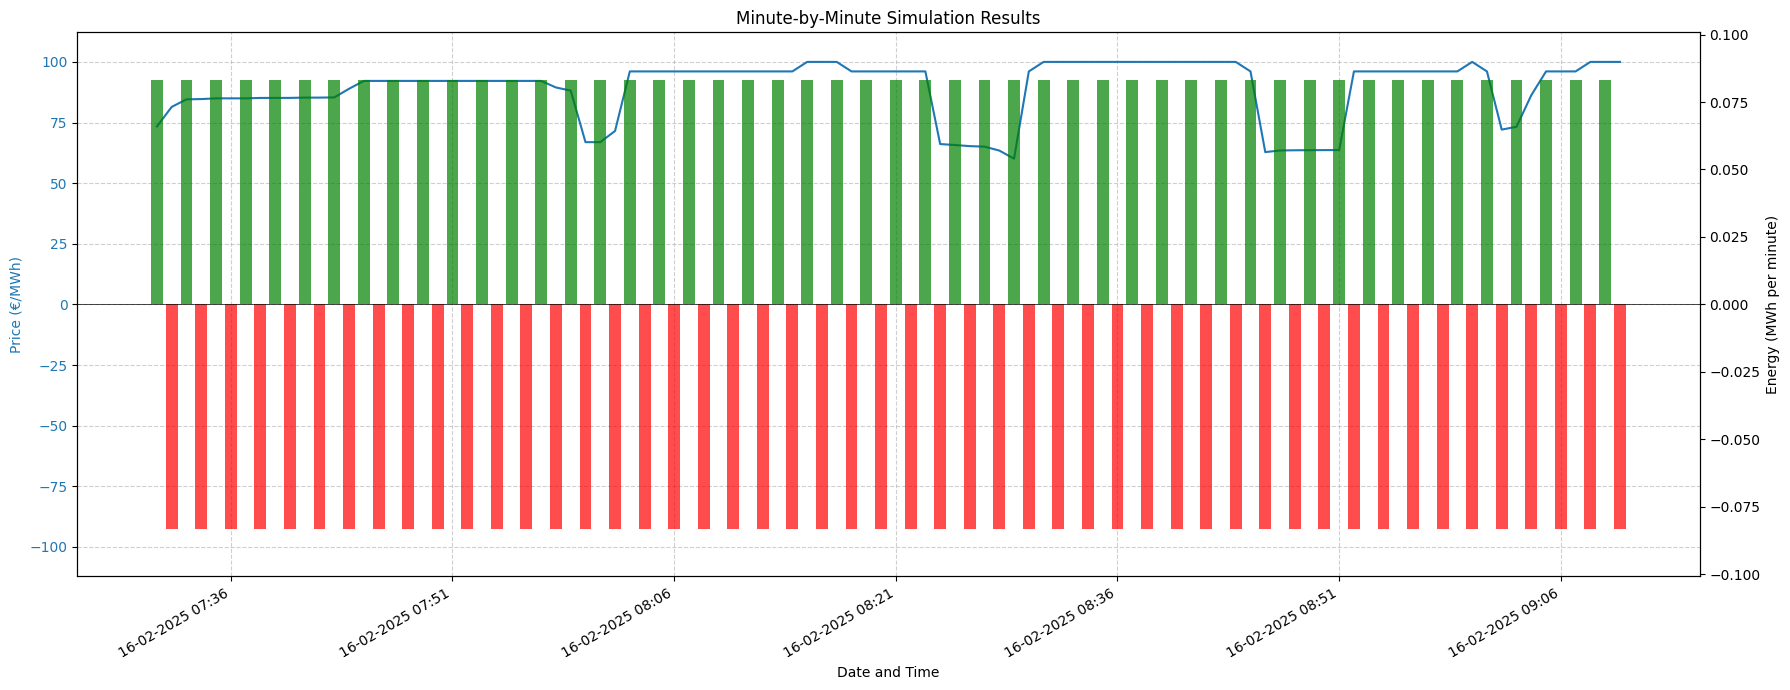

In [59]:
plot_simulation_results_minute_by_minute(
    history_df,
    "test_scaling_reward",
    20_500,
    20_600
)

Maybe it sees in the same quarter that it can get a reward by discharging on the positive price. But eventually it will lead to a 0 reward.

Or it thinks that it made a bad decision and tries to revert its decision.

Saving plot to: plots/iets


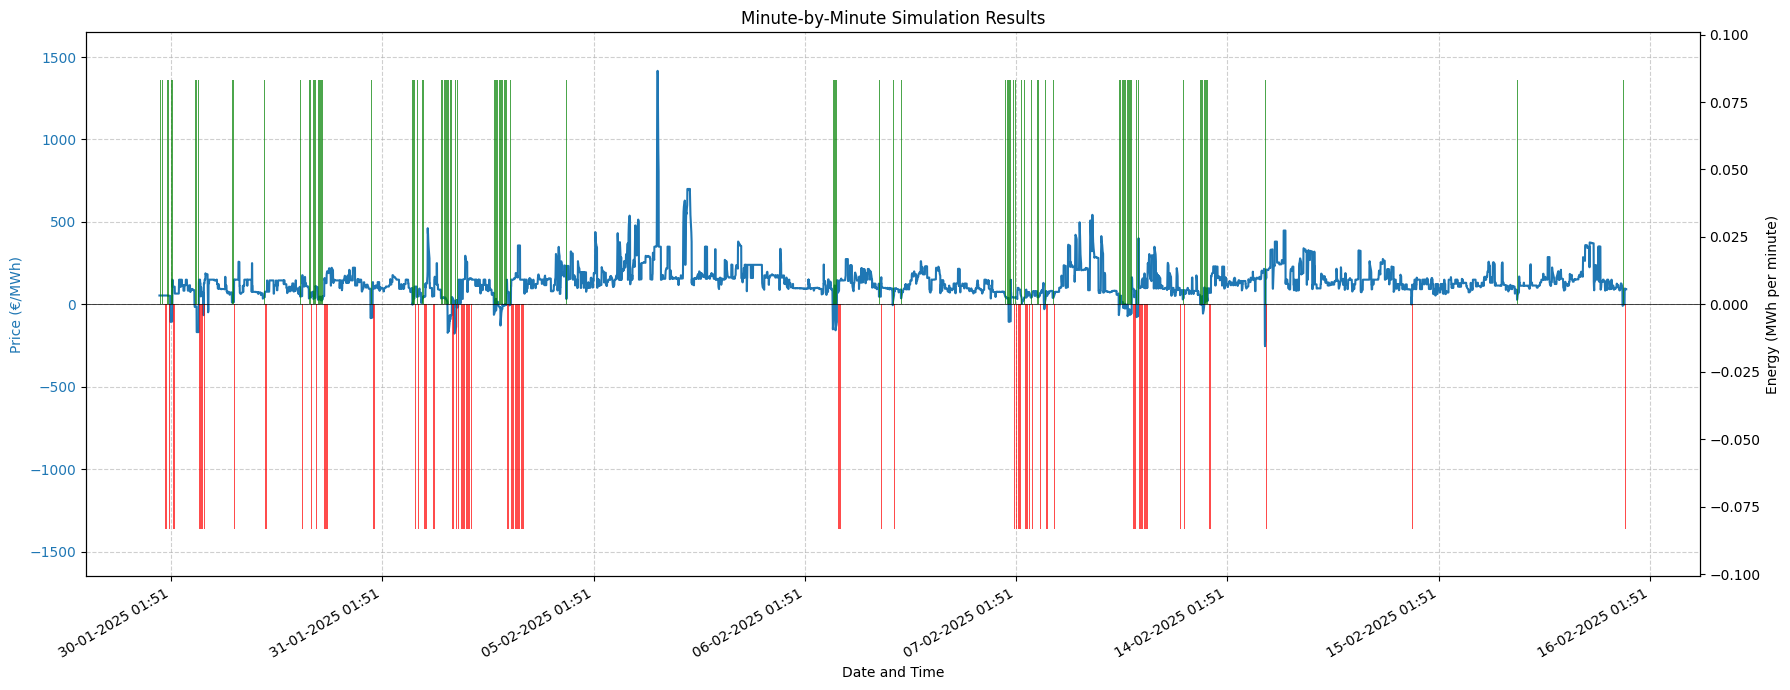

In [18]:
from Simulation.suite_simple_trading.plotting import plot_total_charged_discharged_in_quarter_per_price

plot_simulation_results_minute_by_minute(history_df_compare,
                                                   "iets",
                                                   10_000,
                                                   20_000)

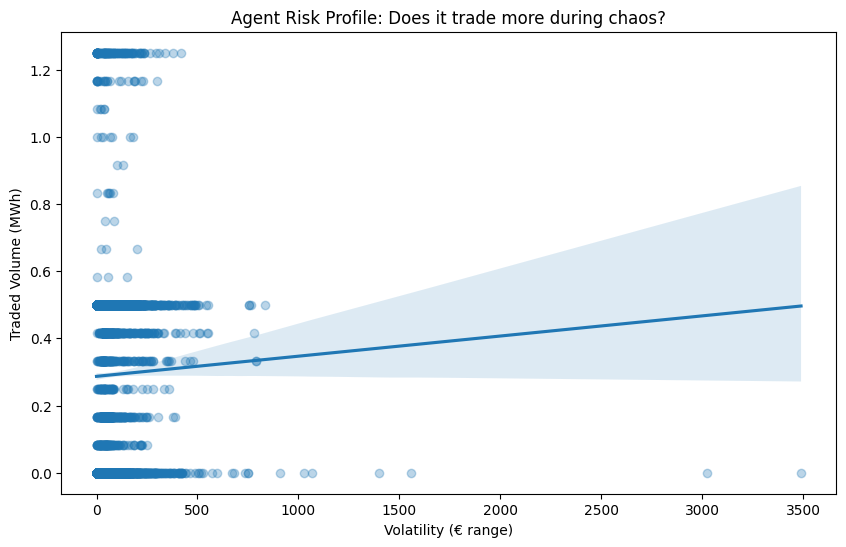

In [40]:
from Simulation.suite_simple_trading.plotting import plot_volatility_vs_activity

plot_volatility_vs_activity(history_df)

/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/plotting.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_names, y=feature_importance, palette='viridis')


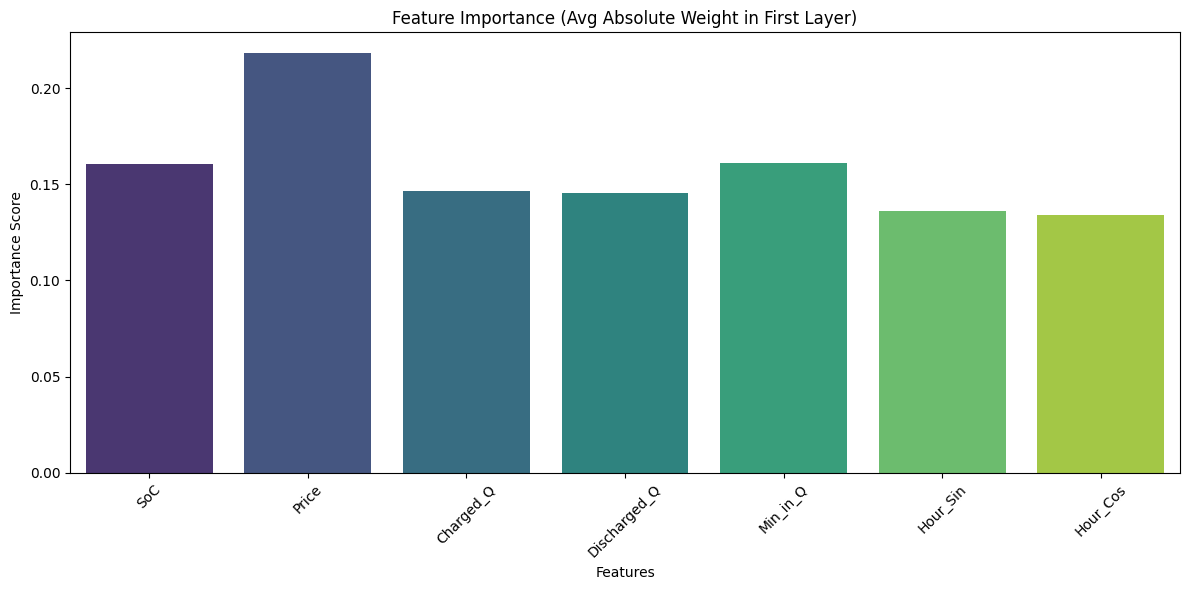

In [33]:
from Simulation.suite_simple_trading.plotting import plot_feature_importance

feature_names = [
    "SoC",
    "Price",
    "Charged_Q",
    "Discharged_Q",
    "Min_in_Q",
    "Hour_Sin", "Hour_Cos",
]
plot_feature_importance(ppo_agent, feature_names)

In [26]:

from stable_baselines3 import DQN

# 1. Create Training Environment
train_env_dqn = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)

# 2. Apply Scaling
train_env_scaled_dqn = RobustScalingWrapper(train_env_dqn)

# 3. Initialize DQN Agent (Standard, not Maskable)
dqn_agent_compare = DQN("MlpPolicy", train_env_scaled_dqn)

# 4. Train
dqn_agent_compare.learn(total_timesteps=200_000, progress_bar=True)

Output()

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [27]:
### Testing
test_env_dqn = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled_dqn = RobustScalingWrapper(test_env_dqn)

# Run Evaluation
result_dqn_compare = run_evaluation(test_env_scaled_dqn,
                            dqn_agent_compare, is_masked=False, number_of_episodes=nr_of_episodes)

print(f"reward dqn: {sum(result_dqn_compare['real_rewards'])}")

# Prepare Dataframe for plotting
if "episodic_rewards" in result_dqn_compare:
    result_dqn_compare.pop("episodic_rewards")

history_df_dqn = pd.DataFrame(result_dqn_compare)
# Reset index to ensure alignment with the simulation results
history_df_dqn['Datetime'] = test_df['Datetime'].reset_index(drop=True)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 958.88
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 41.58
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 242.07
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 236.59
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 122.61
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 949.43
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total (scaled

Saving plot to: plots/iets


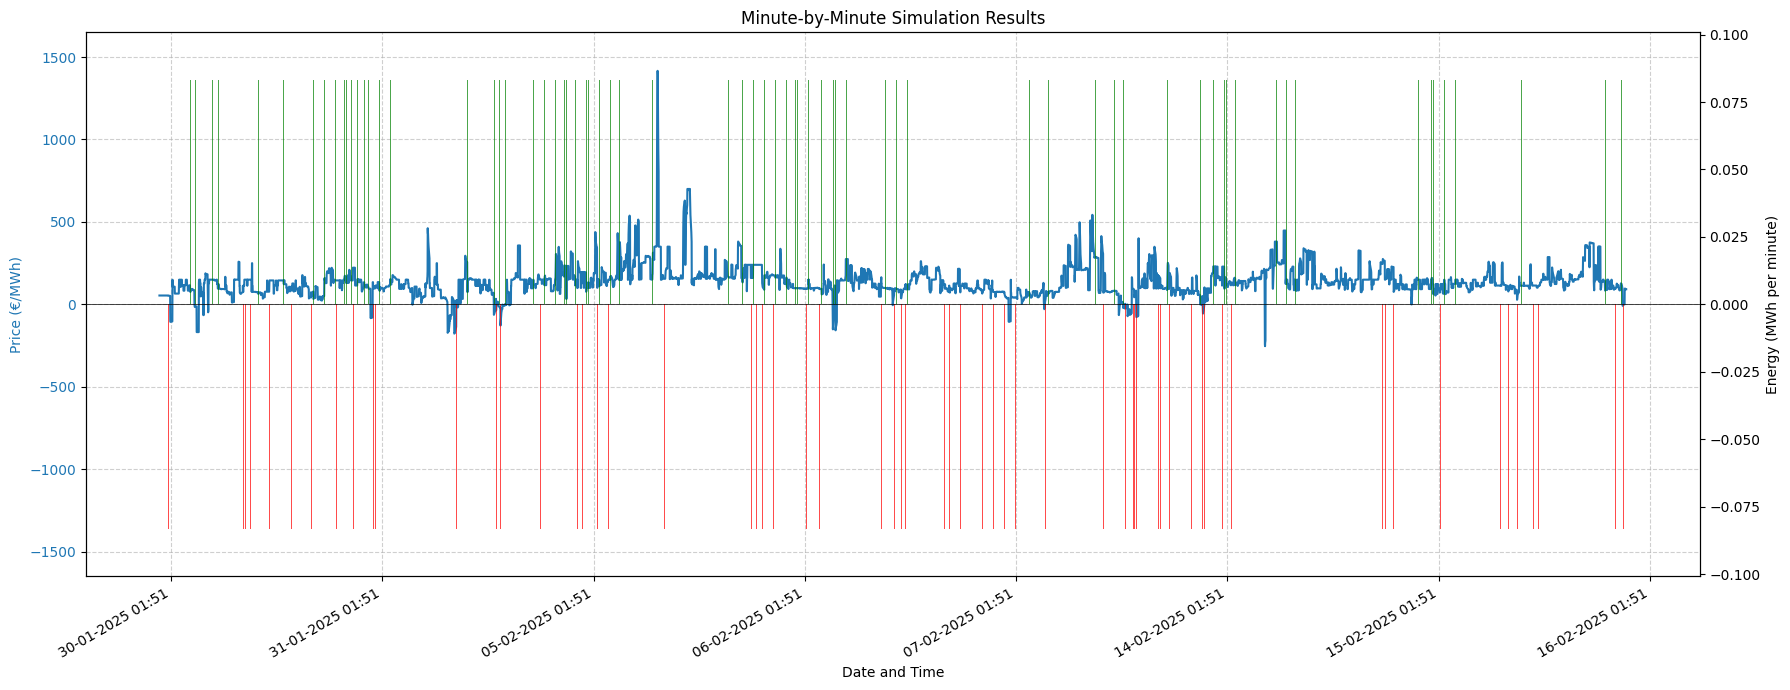

In [28]:

plot_simulation_results_minute_by_minute(history_df_dqn,
                                                   "iets",
                                                   10_000,
                                                   20_000)

Detected DQN architecture.


/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/plotting.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  derived from the 'datetimes' key in the results.


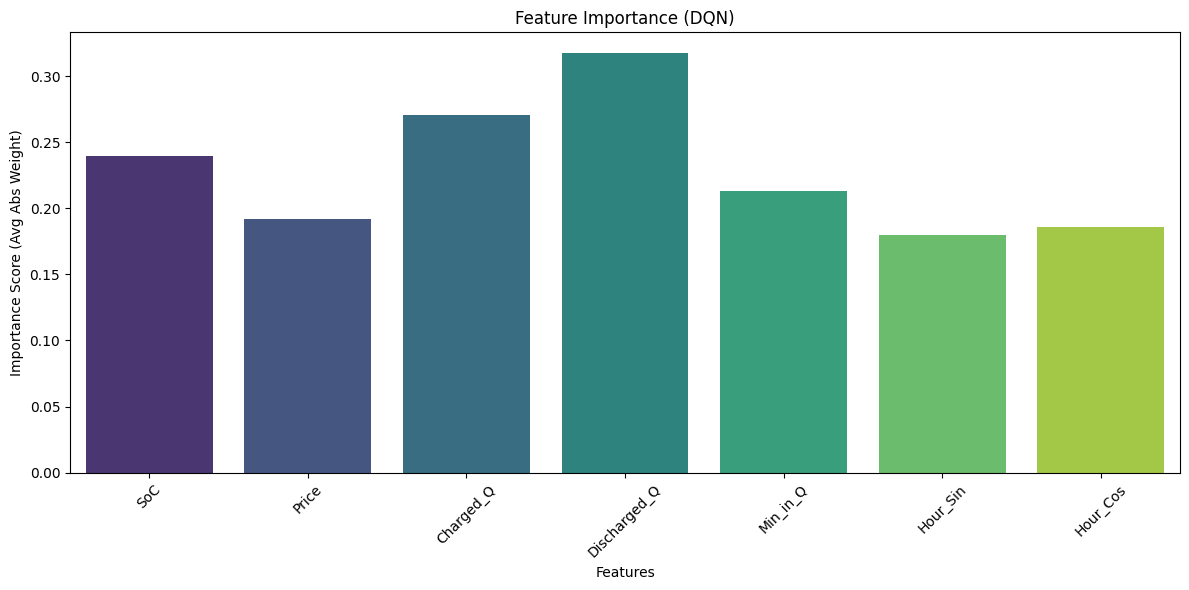

In [35]:
from Simulation.suite_simple_trading.plotting import plot_feature_importance

feature_names = [
    "SoC",
    "Price",
    "Charged_Q",
    "Discharged_Q",
    "Min_in_Q",
    "Hour_Sin", "Hour_Cos",
]
plot_feature_importance(dqn_agent_compare, feature_names)

In [42]:
import gymnasium as gym
class SoCPenaltyWrapper(gym.Wrapper):
    """
    Adds a penalty if the battery is not fully charged, as described in the paper.
    Formula: Penalty = weight * (SoC_max - SoC_current)

    This encourages the agent to keep the battery charged to be ready for price peaks.
    """
    def __init__(self, env: gym.Env, weight: float = 0.1):
        """
        Args:
            env: The environment to wrap.
            weight: The 'omega' parameter from the paper.
                    Controls the strength of the penalty.
                    Start small (e.g., 0.01 or 0.1).
        """
        super().__init__(env)
        self.weight = weight
        # We need to access the max capacity from the base environment
        # Assuming your BaseBatteryEnv has 'battery_capacity_mwh'
        self.soc_max = self.env.unwrapped.battery_capacity_mwh

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # 1. Get the current SoC
        # We access the unwrapped environment to get the true physical value
        current_soc = self.env.unwrapped.soc_mwh

        # 2. Calculate the Penalty (Equation 31)
        # penalty is positive number representing the "cost"
        penalty_value = self.weight * (self.soc_max - current_soc)

        # 3. Subtract penalty from the reward
        new_reward = reward - penalty_value

        # 4. Optional: Log for debugging
        info['soc_penalty'] = penalty_value
        info['original_reward'] = reward

        return obs, new_reward, terminated, truncated, info

In [44]:
train_env_reward_shaping = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_shaped = SoCPenaltyWrapper(train_env_reward_shaping, weight=0.05)

train_env_scaled_shaped = RobustScalingWrapper(train_env_shaped)
ppo_agent_shaped = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_shaped)
ppo_agent_shaped.learn(total_timesteps=200_000, progress_bar=True)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---


AttributeError: 'SoCPenaltyWrapper' object has no attribute 'battery_capacity_mwh'